In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from PCMM.PCMMnumpy import ACG
from PCMM import mixture_EM_loop

In [2]:
# make two oscillating signals. In the first quarter of the time series they should be in phase, in the second quarter they should be slightly out-of-phase where signal1 precedes signal2, in the fourt quarter they should be in anti-phase, and in the fourth quarter they should be slightly out-of-phase where signal2 precedes signal1.
n = 1000
noise_level = 0.1
offset = 3
t = np.linspace(0, 3, n)
noises = np.zeros((2,n))
noises[0] = np.random.normal(0, noise_level, n)
noises[1] = np.random.normal(0, noise_level, n)
signal1 = np.zeros((2,n)) # 
signal1[0] = np.sin(2*np.pi*t) 
signal1[1] = np.sin(2*np.pi*t)-offset
signal2 = np.zeros((2,n))
signal2[0] = np.sin(2*np.pi*t)
signal2[1] = np.sin(2*np.pi*t - np.pi/4)-offset
signal3 = np.zeros((2,n))
signal3[0] = np.sin(2*np.pi*t)
signal3[1] = np.sin(2*np.pi*t - np.pi/2)-offset
signal4 = np.zeros((2,n))
signal4[0] = np.sin(2*np.pi*t)
signal4[1] = np.sin(2*np.pi*t - 7*np.pi/4)-offset
signal5 = np.zeros((2,n))
signal5[0] = np.sin(2*np.pi*t)
signal5[1] = np.sin(2*np.pi*t - np.pi)-offset
signal6 = np.zeros((2,n))
signal6[0] = np.sin(2*np.pi*t)
# signal6[1] = np.random.normal(0, 0.4, n)-offset
signal6[1] = 0.5*np.random.uniform(-1, 1, n)-offset
signals = [signal2, signal4,0, signal1,signal5,0, signal3, signal6, signal1]

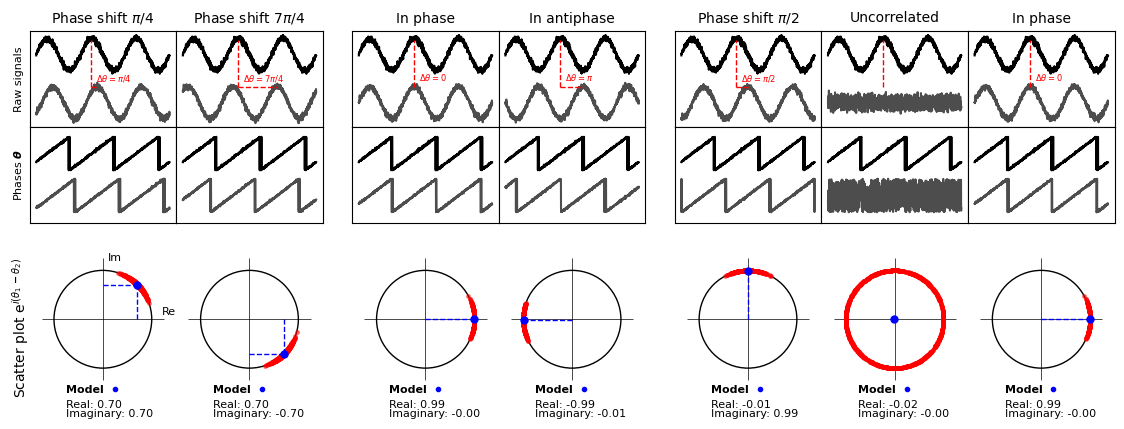

In [ ]:
# plot the signals concatenated
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(3, 9,wspace=0, hspace=0, height_ratios=[1,1,2],width_ratios=[1,1,0.2,1,1,0.2,1,1,1])
axs = gs.subplots()
fontsize=10
colors = [(0,0,0),(0.3,0.3,0.3)]
for i in range(len(signals)):
    if i==2 or i==5:
        axs[0,i].axis('off')
        continue
    for ii in range(2):
        axs[0,i].plot(t,signals[i][ii]+noises[ii],color=colors[ii])
    axs[0,i].set_xticks([])
    axs[0,i].set_yticks([])
    axs[0,i].set_ylim(-4.5, 1.5)
# axs[0,0].set_title('Signals phase-\nshifted by '+r'$\pi/4$',fontsize=fontsize)
# axs[0,1].set_title('Signals phase-\nshifted by '+r'$7\pi/4$',fontsize=fontsize)
# axs[0,3].set_title('Signals in\nphase',fontsize=fontsize)
# axs[0,4].set_title('Signals in\nantiphase',fontsize=fontsize)
# axs[0,6].set_title('Signals phase-\nshifted by '+r'$\pi/2$',fontsize=fontsize)
# axs[0,7].set_title('Signals in\nphase',fontsize=fontsize)
# axs[0,8].set_title('Uncorrelated\nsignals',fontsize=fontsize)
# axs[0,0].set_ylabel('Raw signals', fontsize=8)
axs[0,0].set_title('Phase shift '+r'$\pi/4$',fontsize=fontsize)
axs[0,1].set_title('Phase shift '+r'$7\pi/4$',fontsize=fontsize)
axs[0,3].set_title('In phase',fontsize=fontsize)
axs[0,4].set_title('In antiphase',fontsize=fontsize)
axs[0,6].set_title('Phase shift '+r'$\pi/2$',fontsize=fontsize)
axs[0,8].set_title('In phase',fontsize=fontsize)
axs[0,7].set_title('Uncorrelated',fontsize=fontsize)
axs[0,0].set_ylabel('Raw signals', fontsize=8)

# add a line bar to indicate statistical significance
a = 2*np.pi
offs = 0.01
axs[0,0].vlines(5*np.pi/2/a-offs, -2, 0.9, color='red', linestyle='--', linewidth=1)
axs[0,0].hlines(-2, 5*np.pi/2/a-offs, 11*np.pi/4/a-offs, color='red', linestyle='--', linewidth=1)
axs[0,1].vlines(5*np.pi/2/a-offs, -2, 0.9, color='red', linestyle='--', linewidth=1)
axs[0,1].hlines(-2, 5*np.pi/2/a-offs, 17*np.pi/4/a-offs, color='red', linestyle='--', linewidth=1)
axs[0,3].vlines(5*np.pi/2/a-offs, -2, 0.9, color='red', linestyle='--', linewidth=1)
# axs[0,3].hlines(-2, 5*np.pi/2/a-offs, 11*np.pi/2/a-offs, color='red', linestyle='--', linewidth=1)
axs[0,4].vlines(5*np.pi/2/a-offs, -2, 0.9, color='red', linestyle='--', linewidth=1)
axs[0,4].hlines(-2, 5*np.pi/2/a-offs, 14*np.pi/4/a-offs, color='red', linestyle='--', linewidth=1)
axs[0,6].vlines(5*np.pi/2/a-offs, -2, 0.9, color='red', linestyle='--', linewidth=1)
axs[0,6].hlines(-2, 5*np.pi/2/a-offs, 12*np.pi/4/a-offs, color='red', linestyle='--', linewidth=1)
axs[0,8].vlines(5*np.pi/2/a-offs, -2, 0.9, color='red', linestyle='--', linewidth=1)
# axs[0,7].hlines(-2, 5*np.pi/2/a-offs, 14*np.pi/4/a-offs, color='red', linestyle='--', linewidth=1)
axs[0,7].vlines(5*np.pi/2/a-offs, -2, 0.9, color='red', linestyle='--', linewidth=1)
# axs[0,8].hlines(-2, 5*np.pi/2/a-offs, 3, color='red', linestyle='--', linewidth=1)
axs[0,0].text(5*np.pi/2/a+0.1, -1.64, r'$\Delta\theta=\pi/4$', color='red', fontsize=6)
axs[0,1].text(5*np.pi/2/a+0.1, -1.64, r'$\Delta\theta=7\pi/4$', color='red', fontsize=6)
axs[0,3].text(5*np.pi/2/a+0.1, -1.64, r'$\Delta\theta=0$', color='red', fontsize=6)
axs[0,4].text(5*np.pi/2/a+0.1, -1.64, r'$\Delta\theta=\pi$', color='red', fontsize=6)
axs[0,6].text(5*np.pi/2/a+0.1, -1.64, r'$\Delta\theta=\pi/2$', color='red', fontsize=6)
axs[0,8].text(5*np.pi/2/a+0.1, -1.64, r'$\Delta\theta=0$', color='red', fontsize=6)
# axs[0,8].text(5*np.pi/2/a+0.1, -1.6, r'$\Delta\theta$ undefined', color='red', fontsize=6)

for i in range(len(signals)):
    if i==2 or i==5:
        axs[1,i].axis('off')
        continue
    sig1 = signals[i][0]+noises[0]
    sig2 = signals[i][1]+noises[1]
    hil1 = np.angle(hilbert(sig1-np.mean(sig1)))
    hil2 = np.angle(hilbert(sig2-np.mean(sig2)))-2.5*np.pi
    hils = np.array([hil1, hil2])
    for ii in range(2):
        axs[1,i].plot(hils[ii], color=colors[ii])
    axs[1,i].set_xticks([])
    axs[1,i].set_yticks([])
    axs[1,i].set_ylim(-13, 5)
axs[1,0].set_ylabel(r'Phases $\boldsymbol{\theta}$', fontsize=8)

for i in range(len(signals)):
    if i==2 or i==5:
        axs[2,i].axis('off')
        continue
    axs[2,i].set_aspect('equal')
    axs[2,i].add_artist(plt.Circle((0, 0), 1, fill=False))
    axs[2,i].set_xlim(-1.5, 1.5)
    axs[2,i].set_ylim(-1.5, 1.5)
    axs[2,i].set_xticks([])
    axs[2,i].set_yticks([])
    axs[2,i].vlines(0, -1.25, 1.25, color='black', linewidth=0.5)
    axs[2,i].hlines(0, -1.25, 1.25, color='black', linewidth=0.5)
    axs[2,i].axis('off')
    sig1 = signals[i][0]+noises[0]
    sig2 = signals[i][1]+noises[1]
    hil1 = np.angle(hilbert(sig1-np.mean(sig1)))
    hil2 = np.angle(hilbert(sig2-np.mean(sig2)))
    # inp1 = (np.cos(hil1)+1j*np.sin(hil1))/np.sqrt(2)
    # inp2 = (np.cos(hil2)+1j*np.sin(hil2))/np.sqrt(2)
    # hils = np.array([inp1, inp2])
    # model = ACG(p=2,complex=True)
    # out = mixture_EM_loop.mixture_EM_loop(model,data=hils.T,init='diametrical_clustering')
    # fit = out[0]['Psi'][0,0,1]
    fit = np.mean(np.exp(1j*(hil1-hil2)))
    circular_difference_signal = hil1-hil2
    axs[2,i].plot(np.cos(circular_difference_signal), np.sin(circular_difference_signal), 'r.', alpha=0.5, markersize=5)
    axs[2,i].plot(np.real(fit), np.imag(fit), 'b.', alpha=1, markersize=10)

    # add lines from the fit to the real and imaginary axes
    axs[2,i].hlines(np.imag(fit), 0, np.real(fit), color='blue', linestyle='--', linewidth=1)
    axs[2,i].vlines(np.real(fit), 0, np.imag(fit), color='blue', linestyle='--', linewidth=1)

    if i==0:
        axs[2,i].text(1.2,0.1,'Re', fontsize=8)
        axs[2,i].text(0.1,1.2,'Im', fontsize=8)
        axs[2,0].text(-1.9,-1.5,r'Scatter plot $\operatorname{e}^{i(\boldsymbol{\theta_1-\theta_2})}$', fontsize=f1,rotation=90)
    # elif i==2:
    #     axs[2,i].legend(handles=[plt.plot([],'r.')[0],plt.plot([],'b.')[0]],labels=[r'$e^{i(\theta_1-\theta2)}$', 'Estimated fit'], loc=(0.65,0.8), fontsize=8,framealpha=0)
    #give some text on the plot displaying the real value, imagunary value and the angle of fit
    axs[2,i].text(-0.75, -1.5, 'Model', fontsize=8,fontweight='bold')
    axs[2,i].plot(0.25,-1.43, 'b.')
    axs[2,i].text(-0.75, -1.8, 'Real: {:.2f}'.format(np.real(fit)), fontsize=8)
    axs[2,i].text(-0.75, -2.0, 'Imaginary: {:.2f}'.format(np.imag(fit)), fontsize=8)
    # axs[2,i].text(-1.1, -1.6, 'Average: {:.2f}'.format(np.real(fit))+r'$+ i$'+'{:.2f}'.format(np.imag(fit)), fontsize=8)
    # axs[2,i].text(-0.75, -2.3, 'Angle: {:.2f}'.format(np.angle(fit)), fontsize=8)
    # axs[2,i].text(-0.75, -2.5, 'Magnitude: {:.2f}'.format(np.abs(fit)), fontsize=8)
# set overarching title
# fig.suptitle('Phase coherence is a complex-valued measure', fontsize=14, fontweight='bold')
fig.savefig('paper/synthetic_analysis/figures/2d_visualization_results.pdf', bbox_inches='tight')

In [7]:
def plot_hilbert_transform_3d(data, t):

    ax = fig.add_subplot(111, projection='3d')
    # background white
    # First remove fill
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    # Now set color to white (or whatever is "invisible")
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')
    axis_loc = 1

    # add a time-axis as an arrow from -5s to 250s
    time_axis_start = 0.1
    # ax.quiver(-time_axis_start, 0,0, t[-1]+2*time_axis_start, 0,0, color='k', arrow_length_ratio=0.01, linewidth=1)

    analytic_signals = []
    # phases = []
    for i in range(data.shape[1]):
        analytic_signal = hilbert(data[:,i] - np.mean(data[:,i]))
        analytic_signals.append(analytic_signal)
        # phases += [np.angle(analytic_signal)]
    # difference_signal = np.exp(1j*(phases[0]-phases[1]))

    # # Imaginary part
    # ax.plot(t, np.imag(difference_signal), -axis_loc*np.ones_like(t), 'k:', label="x_i(t)")

    # # Real part
    # ax.plot(t, axis_loc*np.ones_like(t), np.real(difference_signal), 'k--', label="x_r(t)")

    for i in range(data.shape[1]):
        if i == 0:
            col = 'k'
        else:
            col = 'b'
            # dark blue
            # col = (0,0,0.5)
        analytic_signal = analytic_signals[i]
        x_r = np.real(analytic_signal)
        x_i = np.imag(analytic_signal)
        # ax.plot(t, np.zeros_like(t), np.zeros_like(t), 'k', label="time axis")

        # Analytic signal as 3-D curve (black)
        ax.plot(t, x_r, x_i, col, linewidth=2, label="analytic signal x_c(t)")

        # ax.plot(t,axis_loc*np.ones_like(t), x_r, col, linestyle='--', linewidth=1, label="real part x_r(t)")

        # # add arrows at selected time-points 
        # selected_timepoints = [250,500]
        # for i in selected_timepoints:
        #     ax.quiver(t[i], 0,0, 0, x_r[i], x_i[i], color=col,linestyle='--', arrow_length_ratio=0.1)
        # for i in range(0, len(t),100):
        #     ax.quiver(t[i], 0,0, 0, x_r[i], x_i[i], color='red', arrow_length_ratio=0.1)


    # ax.set_xlim([t[0], t[-1]])
    ax.set_ylim([-axis_loc,axis_loc])
    ax.set_zlim([-axis_loc,axis_loc])

    # ax.set_xticks([0,50,100,150,200])
    ax.set_yticks([-1,0,1],labels=[])
    ax.set_zticks([-1,0,1],labels=[])
    ax.set_xticks([0,1,2,3],labels=[0,1,2,3],fontsize=12)  # hide the time ticks    
    # ax.tick_params(axis='both', which='both', length=0)  # hide the time ticks
    # ax.set_yticks([])
    # ax.set_zticks([])

    # ----- labels / view -----
    ax.set_xlabel(r'Time ($t$) [seconds]', labelpad=15, fontsize=12)
    ax.set_ylabel("Imaginary axis", labelpad=-15, fontsize=8)
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel("Real axis", labelpad=-15, rotation=90, fontsize=8)

    # set the z-label on the left side
    ax.zaxis.set_label_position('lower')
    # and also the axis itself
    ax.zaxis.set_ticks_position('lower')
    # flip the label 180 degrees

    # put in some text saying cos(phase) and sin(phase)
    # ax.text(180, 2.5, 2, r'$\text{Re}(z(t))$', color='black', fontsize=10)
    # ax.text(180, -2, -3.5, r'$\text{Im}(z(t))$', color='black', fontsize=10)
    # ax.text(0, -2.5, -1.5, r'$z(t)$', color='black', fontsize=10)
    # ax.text(-10, 0, 2, r'$\theta(t)$', color='red', fontsize=10)


    # ax.legend()
    ax.view_init(elev=30, azim=-60)  # set viewing angle similar to your image
    # plt.tight_layout()
    # plt.show()
    return ax

# plt.savefig('paper/synthetic_analysis/figures/hilbert_transform_3d_example.pdf')

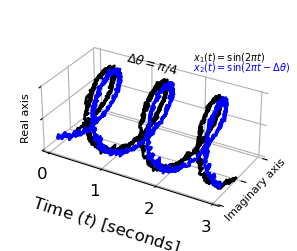

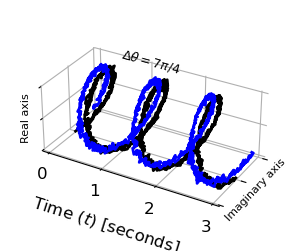

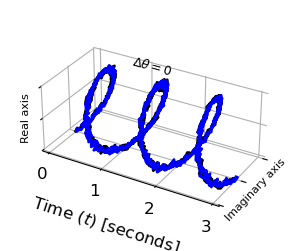

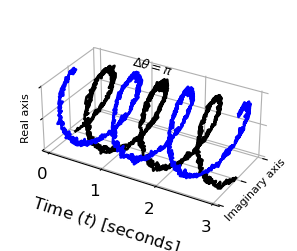

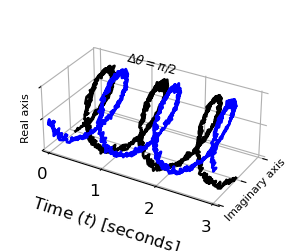

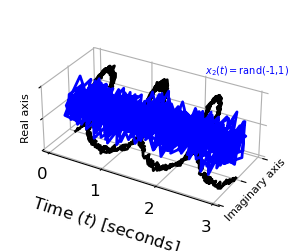

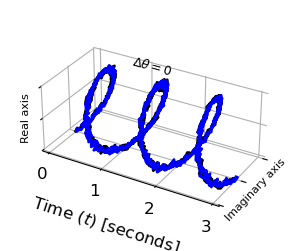

In [12]:
for s in range(len(signals)):
    if s==2 or s==5:
        continue
    
    fig = plt.figure(figsize=(3,3))
    ax = plot_hilbert_transform_3d((signals[s]+noises/2).T, t)
    ax.set_box_aspect([8,4,3])  # set equal aspect ratio
    ax.set_xlim([-0.05,3.05])
    line = getattr(ax, 'yaxis', None)
    line.line.set_visible(False)
    line = getattr(ax, 'zaxis', None)
    line.line.set_visible(False)

    f1 = 9
    f2 = 7
    if s==0:
        ax.text(0.6, 0.8, 0.6, r'$\Delta\theta=\pi/4$', (1,0,0),fontsize=f1)
        ax.text(2.4, -0.5, 2.6, r'$x_1(t)=\sin(2\pi t)$', color='black', fontsize=f2)
        ax.text(2.4, -0.5, 2.3, r'$x_2(t)=\sin(2\pi t - \Delta\theta)$', color='blue', fontsize=f2)
    elif s==1:
        ax.text(0.5, 0.8, 0.6, r'$\Delta\theta=7\pi/4$', (1,0,0), fontsize=f1)
    elif s==3:
        ax.text(0.7, 0.8, 0.6, r'$\Delta\theta=0$', (1,0,0), fontsize=f1)
    elif s==4:
        ax.text(0.7, 0.8, 0.6, r'$\Delta\theta=\pi$', (1,0,0), fontsize=f1)
    elif s==6:
        ax.text(0.6, 0.8, 0.6, r'$\Delta\theta=\pi/2$', (1,0,0), fontsize=f1)
    elif s==7:
        ax.text(2.4, 0, 1.9, r'$x_2(t)=\text{rand(-1,1)}$', color='blue', fontsize=f2)
    elif s==8:
        ax.text(0.7, 0.8, 0.6, r'$\Delta\theta=0$', (1,0,0), fontsize=f1)

    plt.savefig('paper/synthetic_analysis/figures/hilbert_transform_3d_example_signal{}.pdf'.format(s+1), bbox_inches='tight')
